In [16]:
import sqlite3
import pandas as pd

# 1. Crear la conexión a tu base de datos local
conn = sqlite3.connect('mundial2026.db')

# 2. Ver todas las tablas que se crearon en tu base
query_tablas = "SELECT name FROM sqlite_master WHERE type='table';"
tablas = pd.read_sql(query_tablas, conn)
print("Tablas detectadas en la BD:")
print(tablas['name'].tolist())
print("-" * 50)

# 3. Cargar las tablas principales a DataFrames de Pandas
df_teams = pd.read_sql("SELECT * FROM Teams", conn)
df_players = pd.read_sql("SELECT * FROM Players", conn)
df_stats = pd.read_sql("SELECT * FROM Player_Stats", conn)

# 4. Ver el volumen de datos extraídos hasta este momento
print(f"Equipos guardados: {len(df_teams)}")
print(f"Jugadores guardados: {len(df_players)}")
print(f"Registros de estadísticas: {len(df_stats)}")
print("-" * 50)

# 5. Echarle un vistazo a los datos crudos de las estadísticas
# Aquí podrás ver si columnas como 'minutes_played' o 'goals' tienen datos
# y confirmar que 'xg' o 'injury_days_missed' están en 0.
display(df_stats.head(10))

# Cerrar la conexión
conn.close()

Tablas detectadas en la BD:
['Teams', 'Coaches', 'Players', 'Context_Data', 'Player_Stats', 'Coach_Stats']
--------------------------------------------------
Equipos guardados: 47
Jugadores guardados: 839
Registros de estadísticas: 839
--------------------------------------------------


,id,player_id,season,appearances,minutes_played,starts,goals,assists,shots_total,shots_on_target,...,red_cards,injury_days_missed,injuries_last_3seasons,max_altitude_delta_m,min_altitude_delta_m,intl_caps,intl_goals,club_elo_rating,league_rank_europe,updated_at
0,1,1,2024/25,2,90,1,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:29.155163
1,2,2,2024/25,3,188,2,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:30.276078
2,3,3,2024/25,0,0,0,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:31.200439
3,4,4,2024/25,4,240,3,2,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:32.737947
4,5,5,2024/25,0,0,0,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:33.529067
5,6,6,2024/25,0,0,0,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:34.684357
6,7,7,2024/25,2,180,2,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:35.808997
7,8,8,2024/25,2,71,1,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:36.832885
8,9,9,2024/25,1,90,1,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:38.065154
9,10,10,2024/25,3,153,1,0,0,0,0,...,0,0,0,2224.0,-13.0,None,None,None,None,2026-06-09 15:26:39.291381


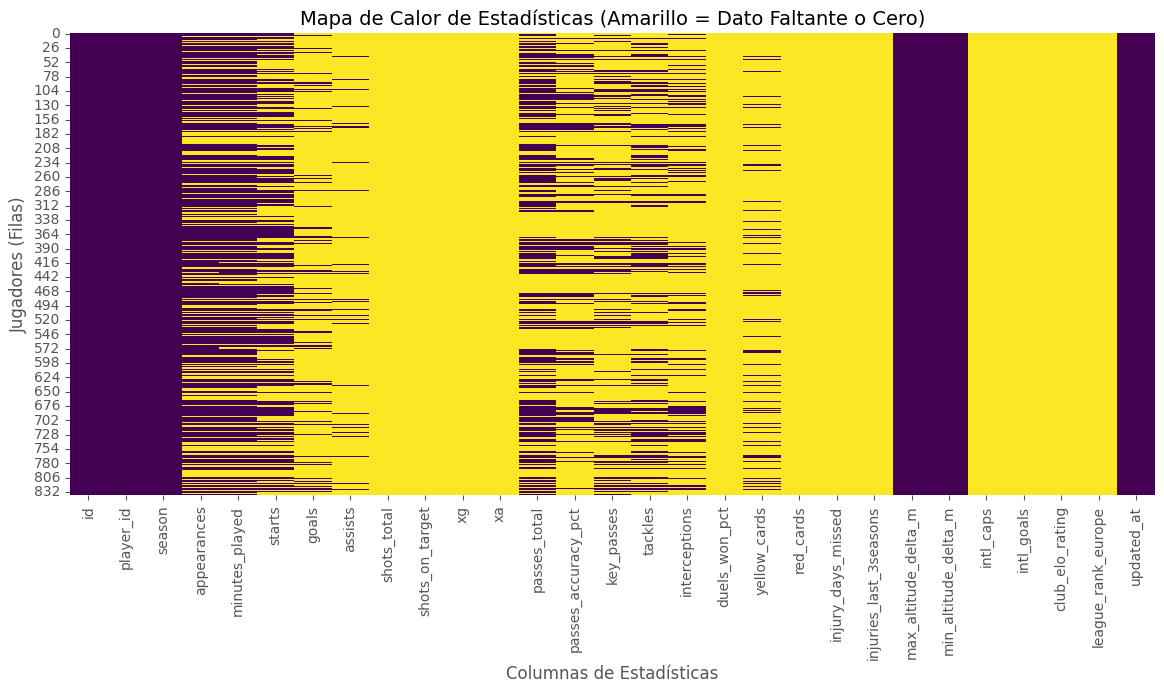

C:\Users\Joshua Sánchez\AppData\Local\Temp\ipykernel_32508\3004407898.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Completitud (%)', y='Variable', data=df_comp, palette='Blues_r')


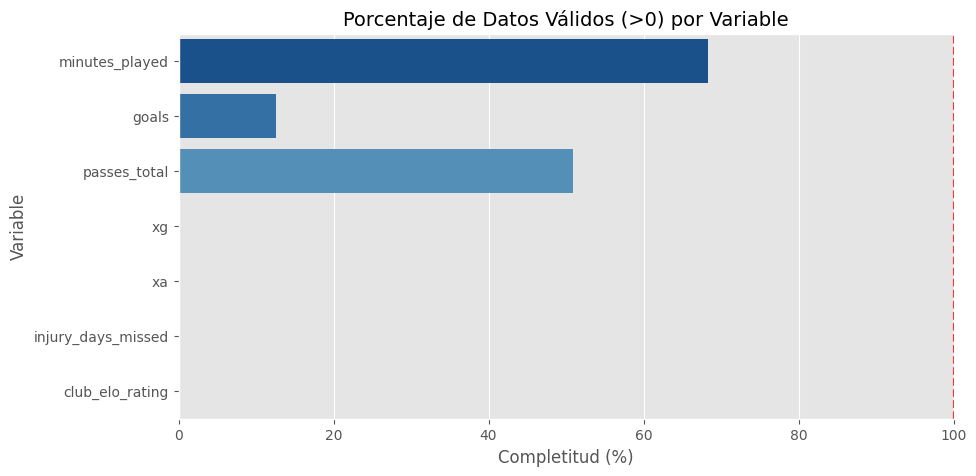

C:\Users\Joshua Sánchez\AppData\Local\Temp\ipykernel_32508\3004407898.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_equipos.index, y=conteo_equipos.values, palette='coolwarm')


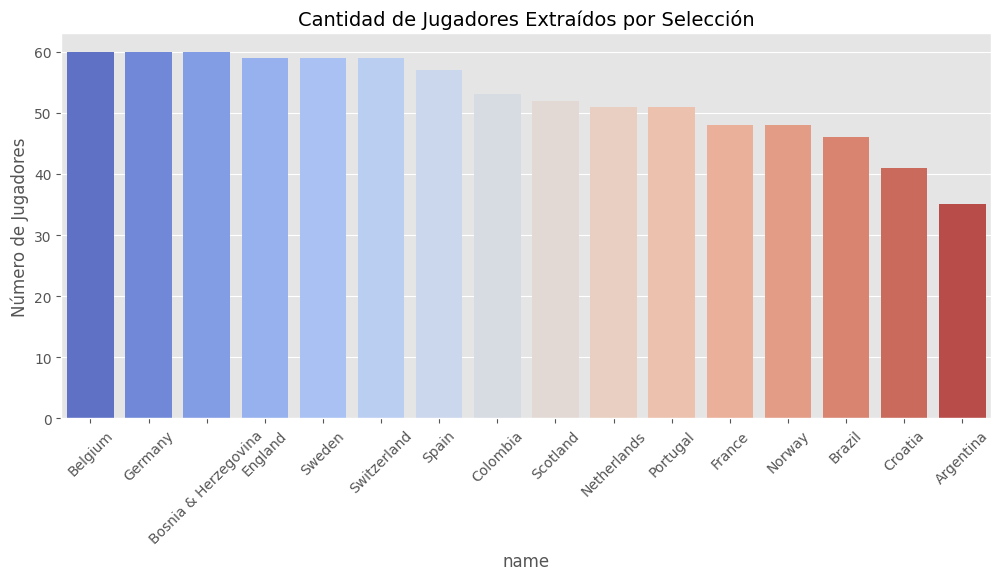

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Asegurarnos de que las gráficas se vean bien en el notebook
plt.style.use('ggplot')

# ---------------------------------------------------------
# GRÁFICA 1: Mapa de Calor de Datos Faltantes (Ceros y Nulos)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
# Convertimos los 0 a NaN solo para propósitos de visualización
df_stats_vis = df_stats.replace({0: np.nan, 0.0: np.nan})

# Creamos un heatmap: Amarillo significa dato faltante/cero, Morado es dato válido
sns.heatmap(df_stats_vis.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Estadísticas (Amarillo = Dato Faltante o Cero)', fontsize=14)
plt.xlabel('Columnas de Estadísticas')
plt.ylabel('Jugadores (Filas)')
plt.show()

# ---------------------------------------------------------
# GRÁFICA 2: Porcentaje de Completitud por Variable Clave
# ---------------------------------------------------------
# Seleccionamos las variables que provienen de distintas APIs
columnas_clave = ['minutes_played', 'goals', 'passes_total', 'xg', 'xa', 
                  'injury_days_missed', 'club_elo_rating']

completitud = []
for col in columnas_clave:
    if col in df_stats.columns:
        # Calculamos qué porcentaje de la columna NO es cero ni nulo
        validos = df_stats[df_stats[col] > 0].shape[0]
        total = df_stats.shape[0]
        pct = (validos / total) * 100 if total > 0 else 0
        completitud.append({'Variable': col, 'Completitud (%)': pct})

df_comp = pd.DataFrame(completitud)

plt.figure(figsize=(10, 5))
sns.barplot(x='Completitud (%)', y='Variable', data=df_comp, palette='Blues_r')
plt.title('Porcentaje de Datos Válidos (>0) por Variable', fontsize=14)
plt.xlim(0, 100)
plt.axvline(x=100, color='red', linestyle='--')
plt.show()

# ---------------------------------------------------------
# GRÁFICA 3: Cantidad de Jugadores Extraídos por Equipo
# ---------------------------------------------------------
# Cruzamos jugadores con equipos para ver sus nombres
df_merged = df_players.merge(df_teams[['id', 'name']], left_on='team_id', right_on='id', suffixes=('', '_team'))

plt.figure(figsize=(12, 5))
conteo_equipos = df_merged['name'].value_counts()
sns.barplot(x=conteo_equipos.index, y=conteo_equipos.values, palette='coolwarm')
plt.title('Cantidad de Jugadores Extraídos por Selección', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Número de Jugadores')
plt.show()

In [19]:
df_merged['name'].unique()

<StringArray>
[             'Belgium',              'Germany',              'England',
 'Bosnia & Herzegovina',              'Croatia',             'Scotland',
                'Spain',               'France',               'Norway',
          'Netherlands',             'Portugal',               'Sweden',
          'Switzerland',            'Argentina',               'Brazil',
             'Colombia']
Length: 16, dtype: str

In [ ]:
import pandas as pd

df = pd.read_csv('world_cup_ml_dataset.csv')

In [ ]:
# Ordenar los equipos únicos en orden alfabético
sorted(df['equipo'].unique())